# EDA housing

## Imports

In [1]:
### library/modules = toolbox

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('housing.csv')

In [3]:
display(data.head(3))
display(data.tail(4))


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


## utilities

In [4]:
def give_INFO(data:pd.DataFrame,sample=False)-> pd.DataFrame:
    
    columns = ['dtypes','nunique','isna_sum']
               #,'sample1','sample2','sample3'] 
    
    DF = pd.concat([data.dtypes,data.nunique(),data.isna().sum()],axis=1)
    DF.columns = columns
    
    
    if sample:
        DF['sample1'] = data.sample().T # sample = 1 random line in dataset
        DF['sample2'] = data.sample().T
        DF['sample3'] = data.sample().T
    
    DF.reset_index(inplace=True)
    return DF


def show_null(data:pd.DataFrame)-> pd.DataFrame:
    
    plt.figure(figsize=(10, 5))

    plt.title('Missing Values\n')

    sns.heatmap(data.isnull(), cbar=False)
    plt.show()

    data.isnull().sum()
    pass

In [5]:
def give_countplots(data:pd.DataFrame,cols:list,hue=None):
    '''provide a picture of subgraphs of countplots
        for each column in 'cols'
        decomposed/grouped by 'hue'
    '''
    
    N_cols = len(cols)
    DF = data[cols] if hue is None else data[[hue]+cols]
    
    
    fig = plt.figure(figsize=(10, 5*N_cols))
    
    for i,col in enumerate(cols):
        plt.subplot(N_cols,1,1+i)
        '''
        if hue is not None:
            plt.title(f'Countplot for {col} by hue = {hue}\n')
        else:
            plt.title(f'Countplot for {col}\n')
        ''' 
        ax = sns.countplot(data=DF, x=col, hue=hue) 

        N_tot = DF[col].count()

        ### show the data-labels for each bar
        for container in ax.containers:
            ## https://stackoverflow.com/questions/31749448/how-to-add-percentages-on-top-of-grouped-bars
            ##labels = [f'{h/data[target].count()*100:0.1f}%' if (h := v.get_height()) > 0 else '' for v in container]


            labels = [] 
            for vbar in container:
                h = vbar.get_height()

                ## add % and count
                str_ = f'{h/N_tot*100:0.1f}% , {int(h)}' if h>0 else ''
                labels.append(str_)

            ax.bar_label(container, labels=labels, label_type='edge')
        plt.xticks(rotation=90)
        plt.tight_layout()
    
    return fig

    

In [6]:
def give_histplots(data:pd.DataFrame,cols:list,hue=None,
                   stat='count',common_norm=True, discrete=False):
    '''histplots of columns in 'cols' decomposed by 'hue'
        stat = 'count', 'percent', 'density' , ... --> see doc seaborn for histplot
        discrete =  each occurence is a bin --> see doc seaborn for histplot
        
        common_norm = if false: when decomposed by 'hue'
            => use groupby(hue) count as ref --> see doc seaborn histplot 
    '''
    N_cols = len(cols)
    DF = data[cols] if hue is None else data[[hue]+cols]
    
    
    fig = plt.figure(figsize=(10, 5*N_cols))
    
    for i,col in enumerate(cols):
        plt.subplot(N_cols,1,1+i)
        '''
        if hue is not None:
            plt.title(f'Countplot for {col} by hue = {hue}\n')
        else:
            plt.title(f'Countplot for {col}\n')
        ''' 
        sns.histplot(data=DF, x=col
                      , fill=True
                      #, element="step" #
                      , stat = stat#'count' # 'count','density','percent', ...
                      , discrete=discrete
                      , kde= not discrete
                      , common_norm=common_norm
                      , hue = hue
                     )

        
        plt.tight_layout()
    
    return fig
    
    

# EDA

## 1. Format-analysis

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


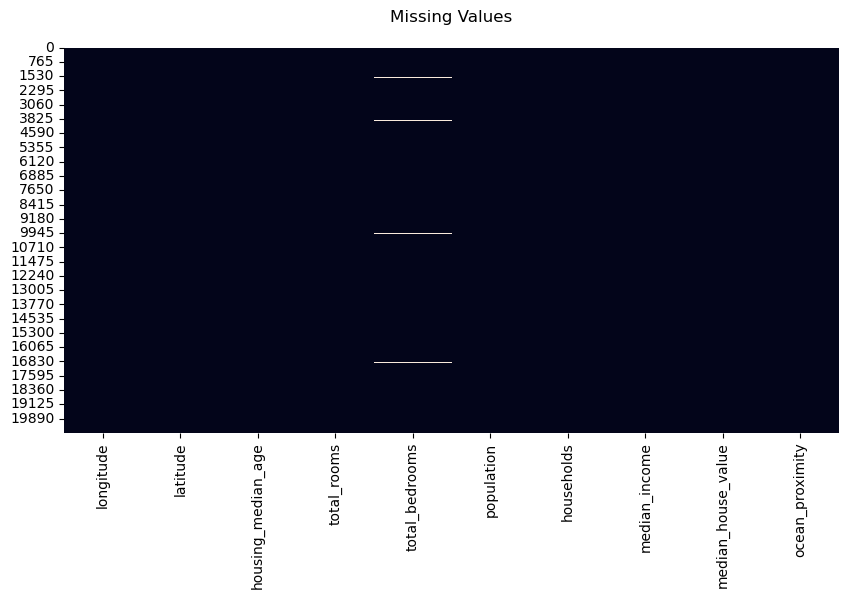

,index,dtypes,nunique,isna_sum
0,longitude,float64,844,0
1,latitude,float64,862,0
2,housing_median_age,float64,52,0
3,total_rooms,float64,5926,0
4,total_bedrooms,float64,1923,207
5,population,float64,3888,0
6,households,float64,1815,0
7,median_income,float64,12928,0
8,median_house_value,float64,3842,0
9,ocean_proximity,object,5,0


data.shape= (20640, 10)


In [8]:
show_null(data)
display(give_INFO(data))
print('data.shape=',data.shape)

## 2. Univariate content-analysis
### 2.a. Target analysis


In [9]:
### referencing for systematic use of this template
target = 'median_house_value'


In [10]:
#give_countplots(data.head(100),[target]) ## not good

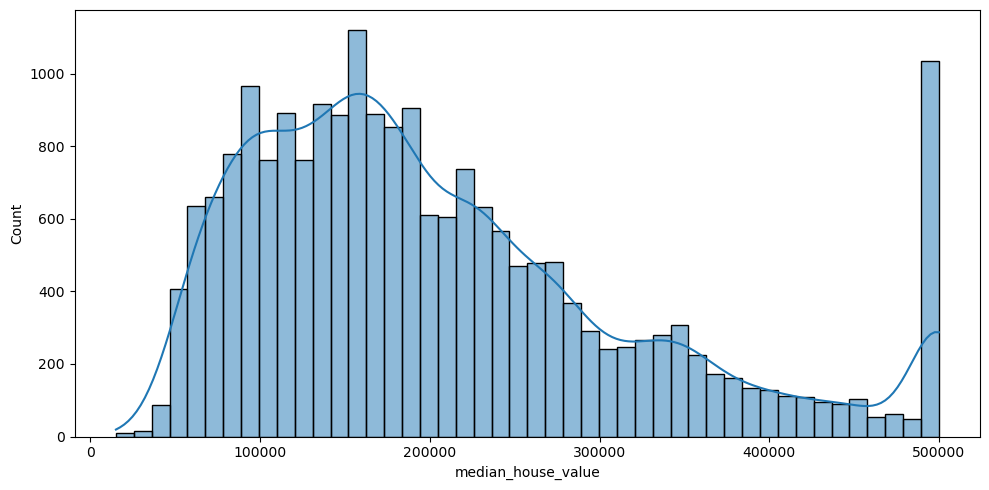

In [11]:
fig = give_histplots(data,[target])

In [12]:
### elementary statistics

data[[target]].describe().T

,count,mean,std,min,25%,50%,75%,max
median_house_value,20640.0,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0


# Bonus what distribution is this

### 2.b. Features analysis: setup

In [13]:
feat_cols = data.columns.to_list()
feat_cols.remove(target)

In [14]:
feat_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'ocean_proximity']

In [15]:

### VERY CRITICAL input from user !!!

### segregation of features into relevant groups of statistical variables

### ordinal_categorical
ord_cols = [] 

### nominal_categorical
nom_cols = ['ocean_proximity'] 


### discrete_numerical

dis_cols = ['housing_median_age',] 
 

### continuous_numerical
con_cols = ['longitude',
 'latitude',
 'median_income',
 ] + ['total_rooms',
 'total_bedrooms',
 'population',
 'households',]


### ------------ ###
### all categorical together
cat_cols = ord_cols + nom_cols 

### all numerical together
num_cols = dis_cols+con_cols


### raise error when (condition not met), (comment of error)
assert len(num_cols)+len(cat_cols) == len(feat_cols), 'non-matching elements'


### 2.c. Categorical features

In [16]:
cat_cols

['ocean_proximity']

In [17]:
display(data[cat_cols].astype('category').describe().T)

,count,unique,top,freq
ocean_proximity,20640,5,<1H OCEAN,9136


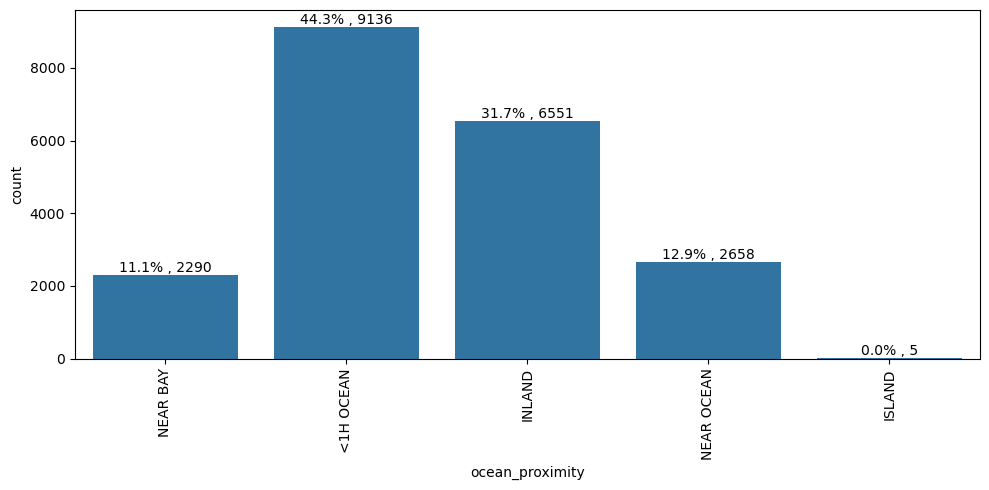

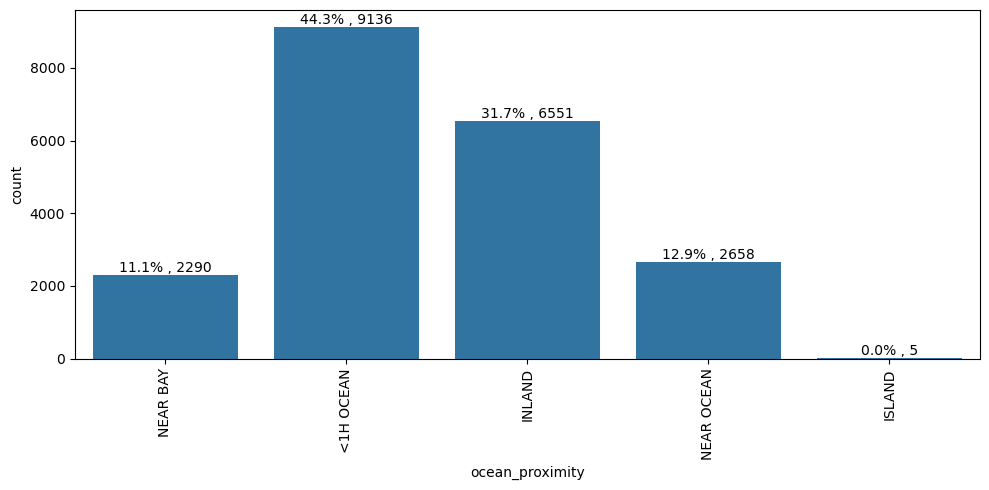

In [36]:
give_countplots(data,cat_cols)


### 2.d. Numerical features

In [18]:
num_cols

['housing_median_age',
 'longitude',
 'latitude',
 'median_income',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households']

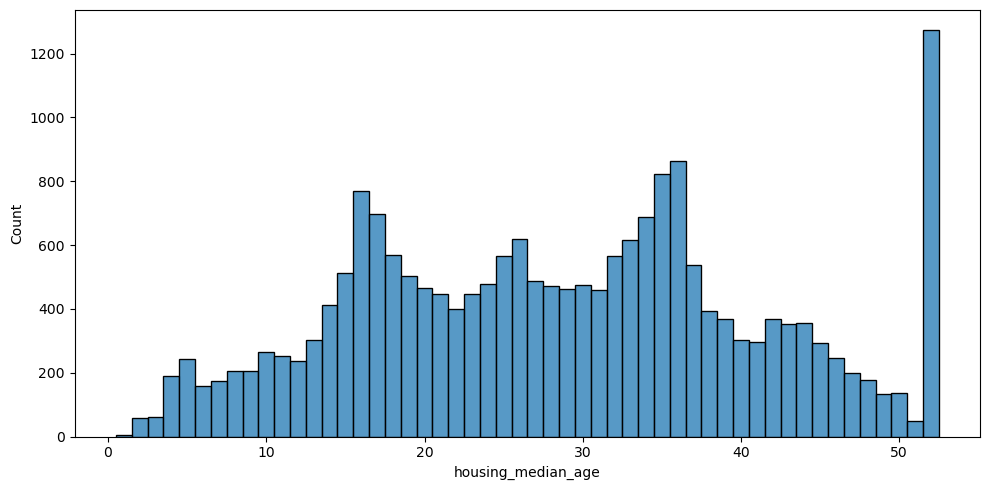

In [19]:
fig = give_histplots(data,dis_cols,discrete=True)

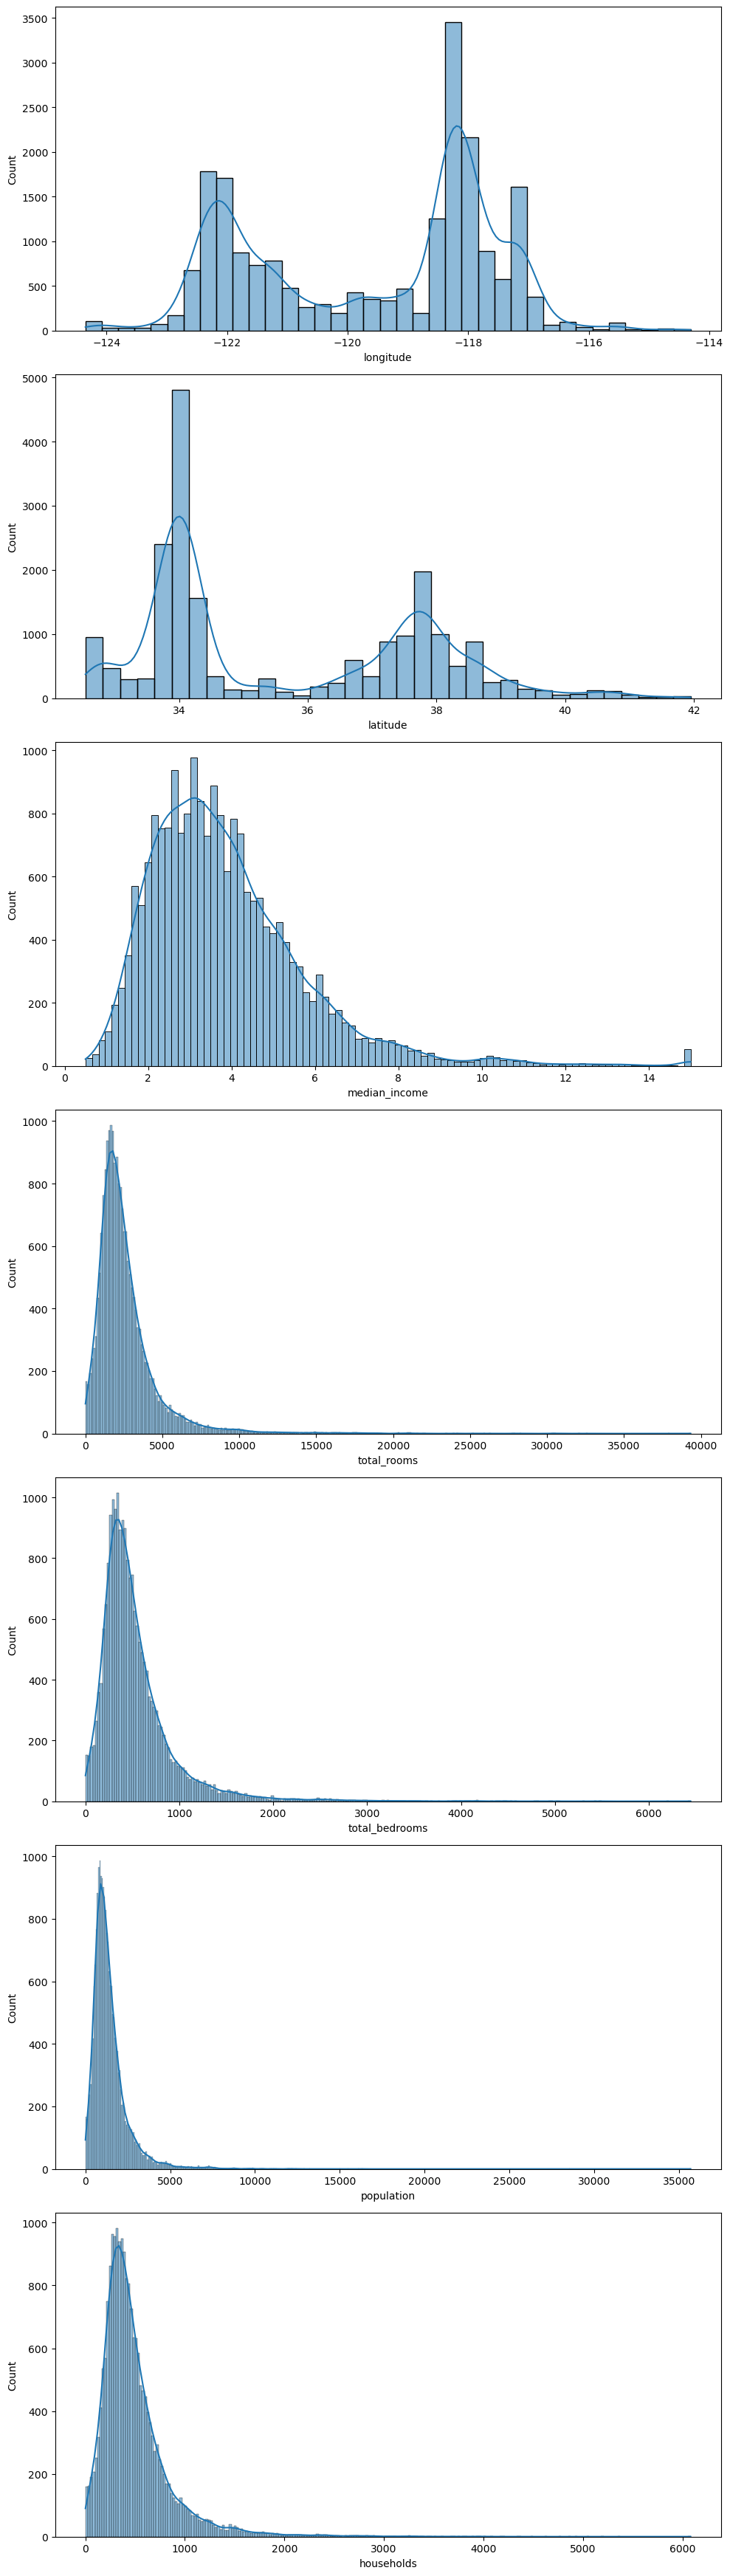

In [20]:
fig = give_histplots(data,con_cols)

In [21]:
display(data[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000


### 2.e. feature engineering for problematic columns discovered in univariate analysis (or before)

## 3. Bivariate content analysis: features vs target




## 3.a.  Categorical vs target


recommendations:  
__feature vs target:__
- _categorical vs categorical:_  
        barplot/countplot/pie-chart of feature,  
        color/hue based on target values  
        
        groupby(target)

- _categorical vs numerical:_  
        histogram of target,  
        color/hue based on feature   
        
        groupby(feature)

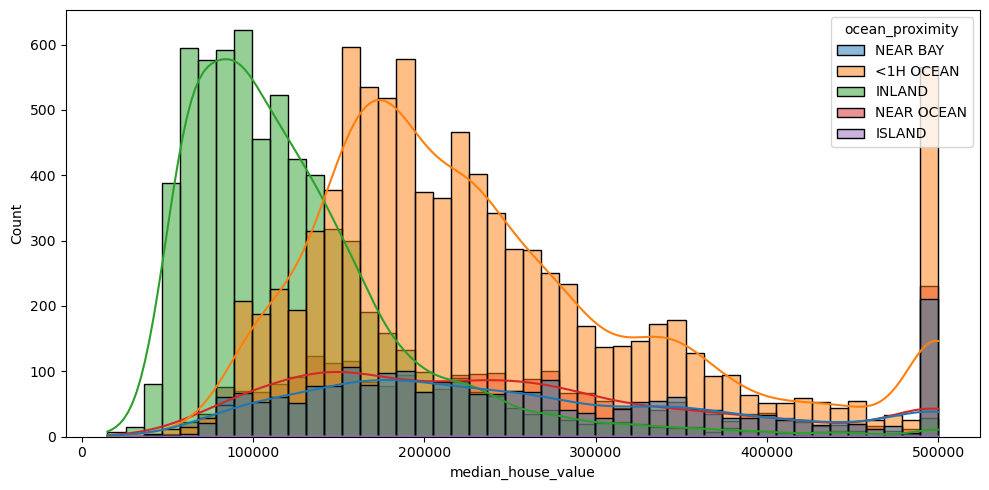

In [22]:
for col in cat_cols:
    give_histplots(data,cols=[target],hue=col)

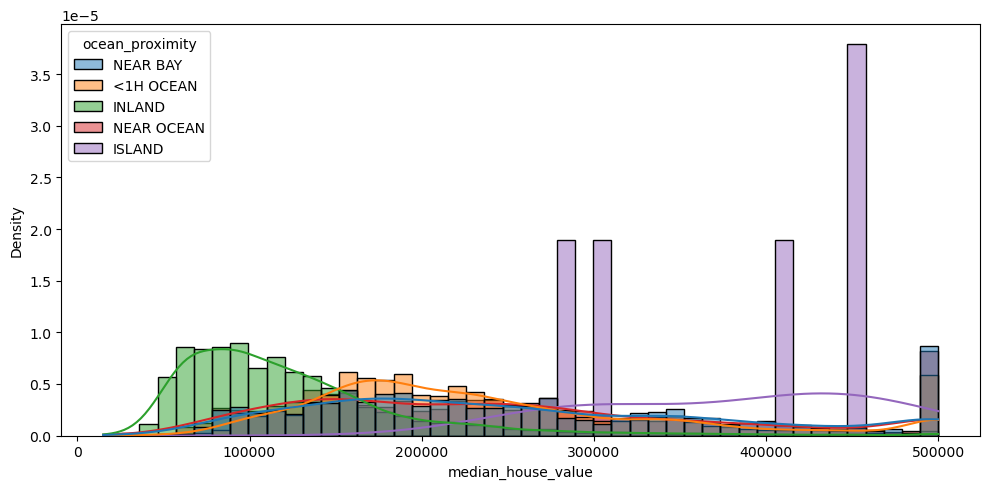

In [23]:
for col in cat_cols:
    give_histplots(data,cols=[target],hue=col,common_norm=False,stat='density')

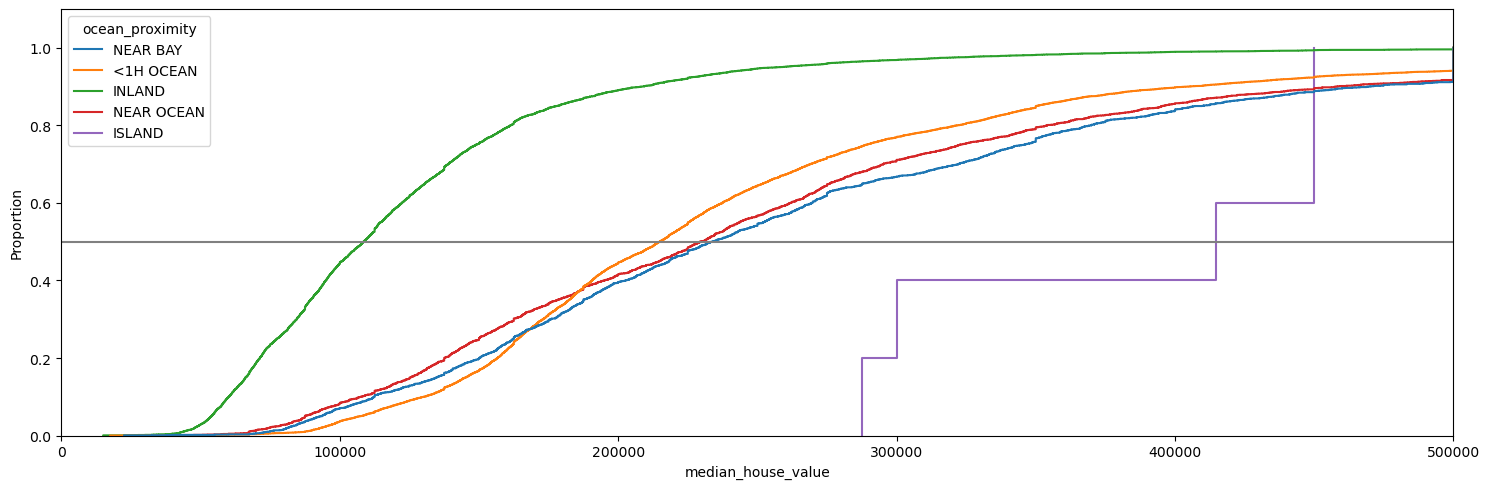

In [24]:
N_cols = len(cat_cols)

plt.figure(figsize=(15,5*N_cols))
for i,col in enumerate(cat_cols):

    plt.subplot(N_cols,1,1+i)
    ### ecdf = empirical cumulated density function
    sns.ecdfplot(data, x= target, hue=col)
    plt.hlines(0.5,xmin=0,xmax = data[target].max(), color='grey')
    plt.axis([0,data[target].max(),0,1.1])
plt.tight_layout()
plt.show()

## 3.b. Numerical vs target


recommendations:  
__feature vs target:__
- _numerical vs categorical:_  
        histogram of feature,  
        color/hue based on target 
        
        groupby(target)
    

- _numerical vs numerical:_  
        scatter/pair plot with 
        feature on x-axis, target on y-axis
        
        no groupby

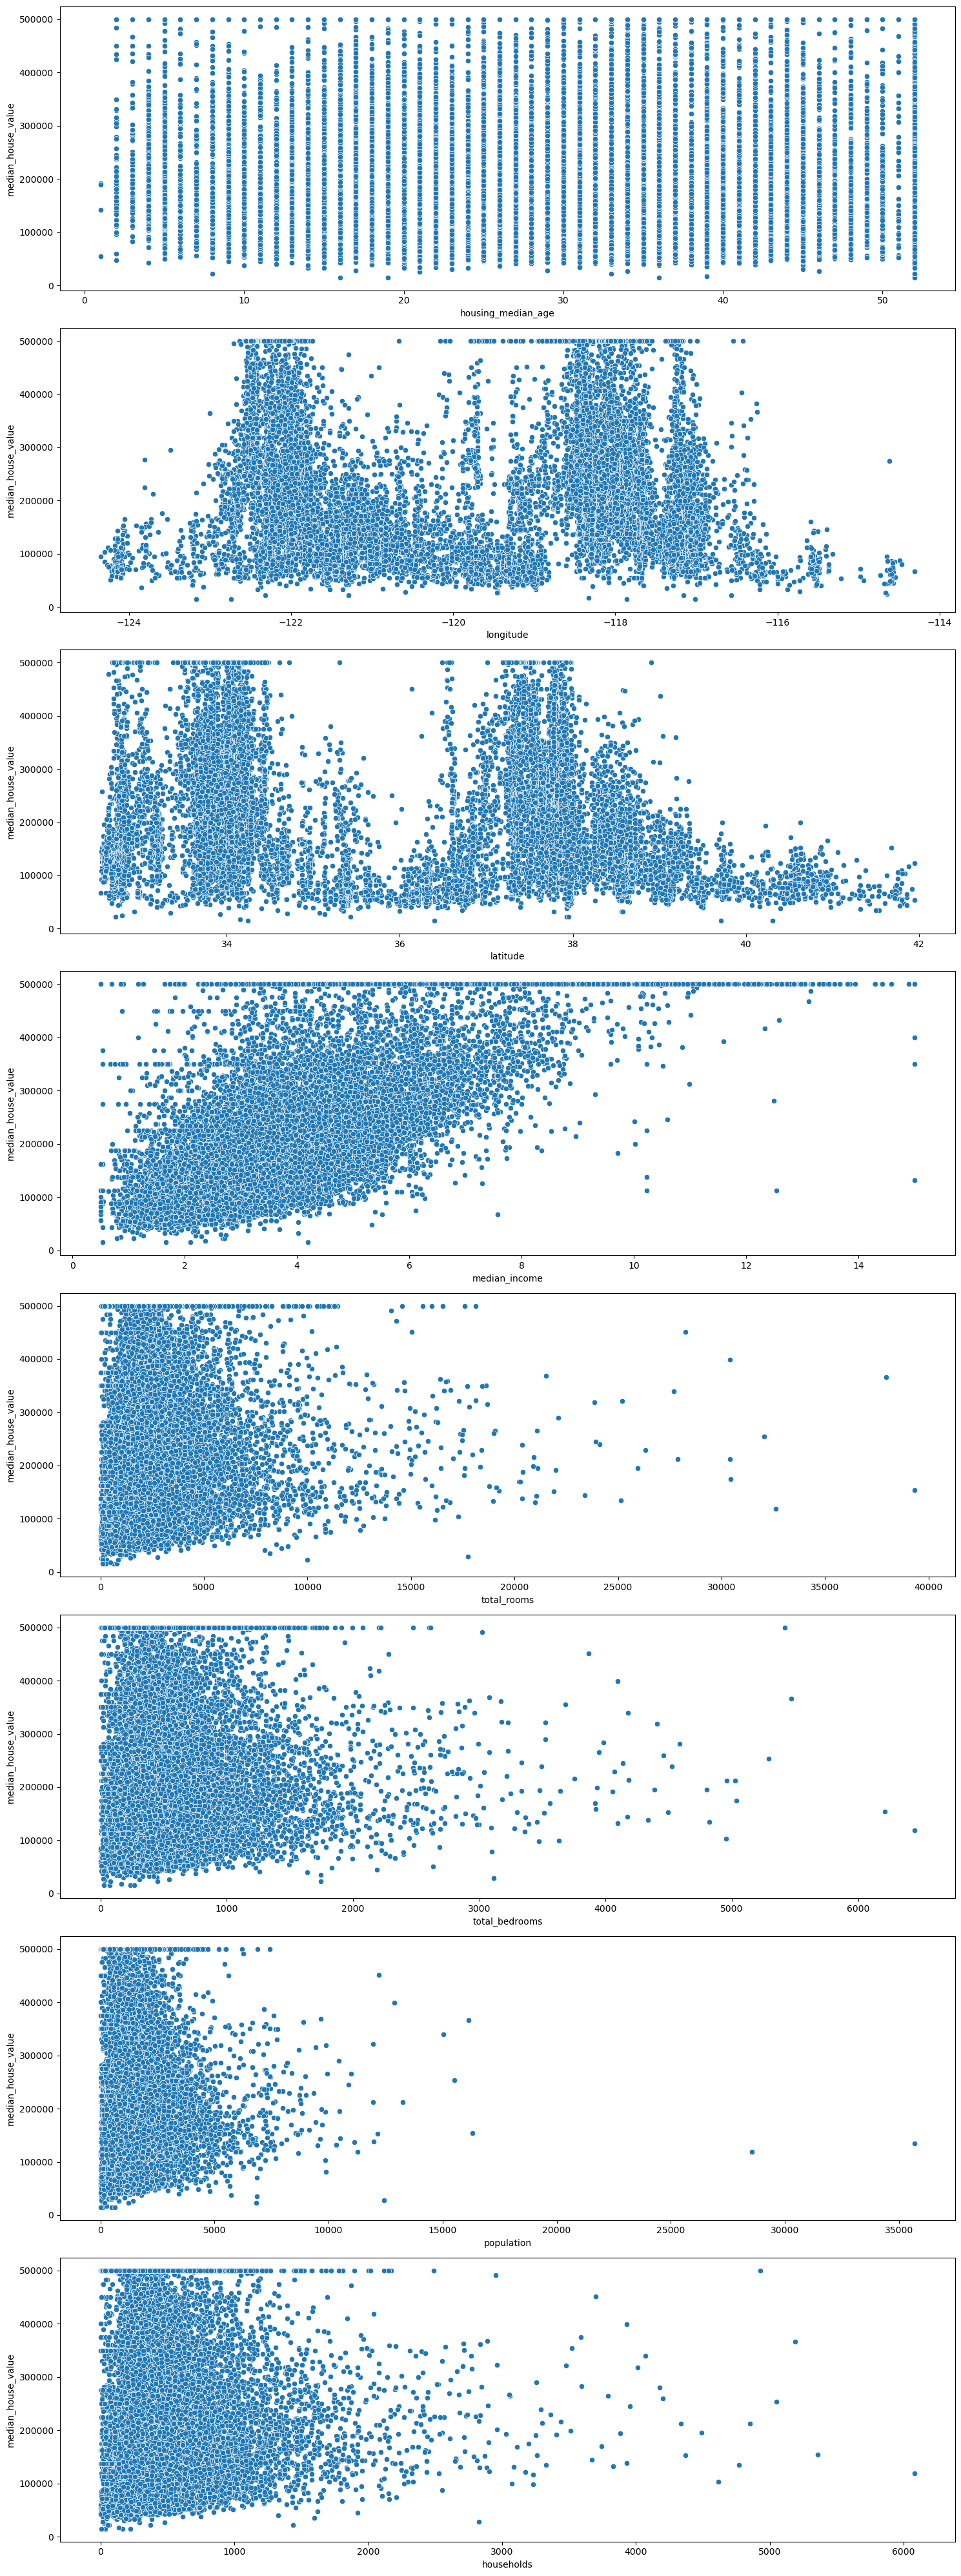

In [25]:
N_cols = len(num_cols)

plt.figure(figsize=(15,5*N_cols))
for i,col in enumerate(num_cols):

    plt.subplot(N_cols,1,1+i)
    sns.scatterplot(data, y= target, x=col)

plt.tight_layout()
plt.show()

## 3.c. Correlations

works only on numbers, not text

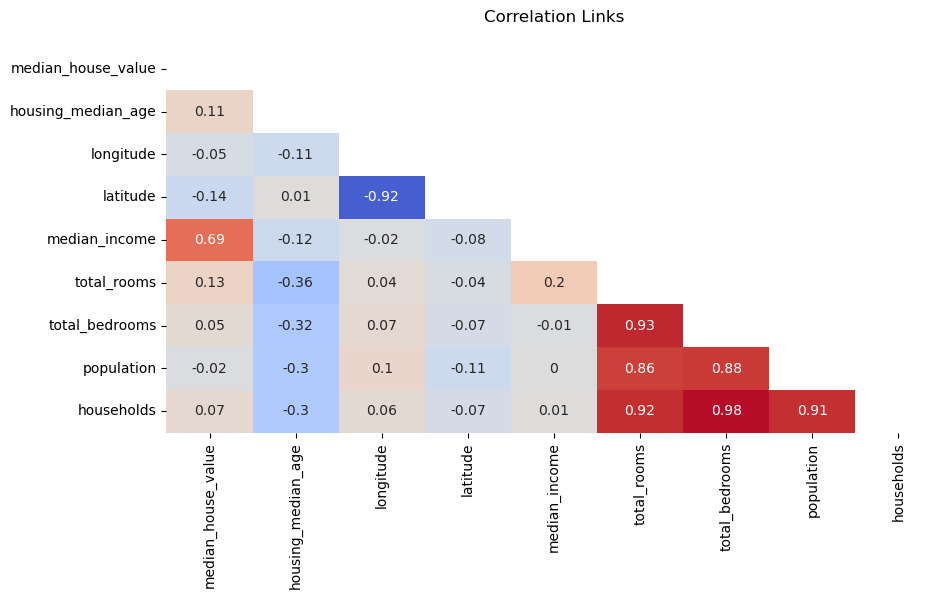

In [26]:
corr_init = data[[target]+num_cols].corr().round(2)

mask = np.triu(np.ones_like(corr_init, dtype=bool))

### put the same info in a graph
plt.figure(figsize=(10, 5))
plt.title('Correlation Links\n')


### heatmap with symetric table
sns.heatmap(data = corr_init,
            vmin=-1,
            vmax=1,
            cmap='coolwarm',
            cbar=False,
            annot=True,
            mask=mask, #mask == hide values
           )
plt.show()


In [27]:
# transformation of categorical columns via onehot-encoding for correlation

In [28]:
temp = pd.get_dummies(data[nom_cols])
display(temp.head(3))
nom_cols_dumm = temp.columns

data3 = pd.concat([data,temp],axis=1)
data3.drop(columns=nom_cols,inplace=True)
data3.head(3)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False


In [29]:
data3.dtypes

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
median_house_value            float64
ocean_proximity_<1H OCEAN        bool
ocean_proximity_INLAND           bool
ocean_proximity_ISLAND           bool
ocean_proximity_NEAR BAY         bool
ocean_proximity_NEAR OCEAN       bool
dtype: object

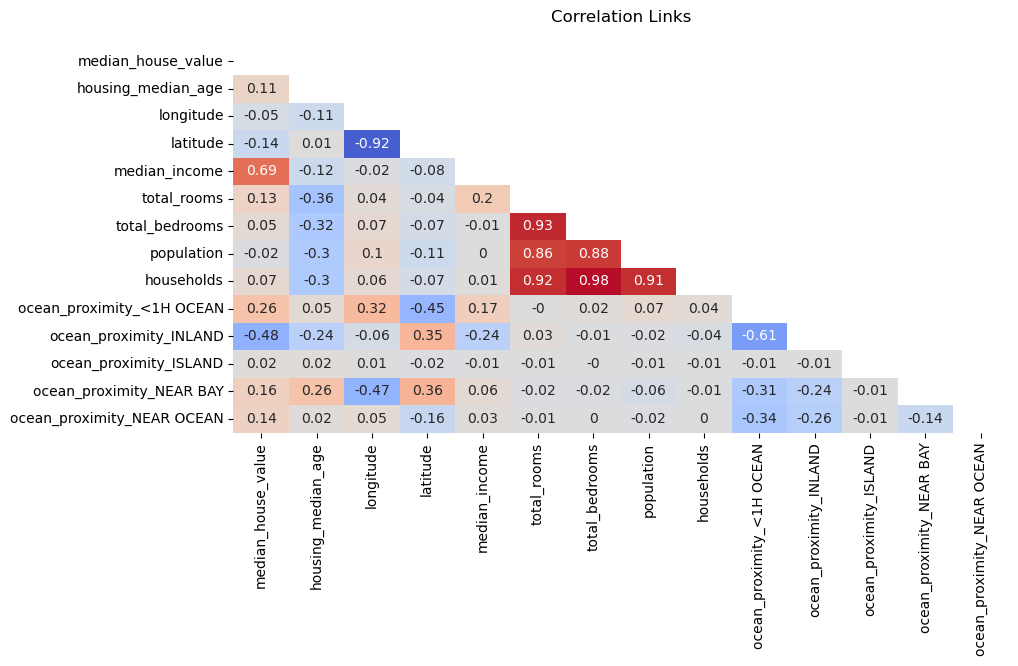

In [30]:
corr_init = data3[[target]+num_cols+nom_cols_dumm.to_list()].corr().round(2)

mask = np.triu(np.ones_like(corr_init, dtype=bool))

### put the same info in a graph
plt.figure(figsize=(10, 5))
plt.title('Correlation Links\n')


### heatmap with symetric table
sns.heatmap(data = corr_init,
            vmin=-1,
            vmax=1,
            cmap='coolwarm',
            cbar=False,
            annot=True,
            mask=mask, #mask == hide values
           )
plt.show()

## 4. Multivariate content analysis
recommendations:

 - try pairplot where applicable
 - groupby where applicable

 - violinplot
>there are no additional general recommendations,
    it depends mostly on context/meaning of the columns

In [31]:
regen = False
if regen:
    plt.figure(figsize=(30,30))
    sns.pairplot(data3,hue=target, corner=True)
    plt.savefig('pairplot_housing.pdf')
    plt.show()

In [32]:
data3.to_csv('housing_modified.csv')

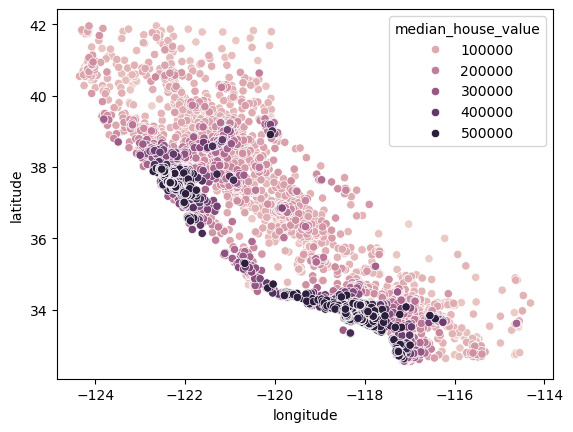

In [37]:
sns.scatterplot(data3.sort_values(by=target), x= 'longitude',y='latitude',hue=target)
plt.show()

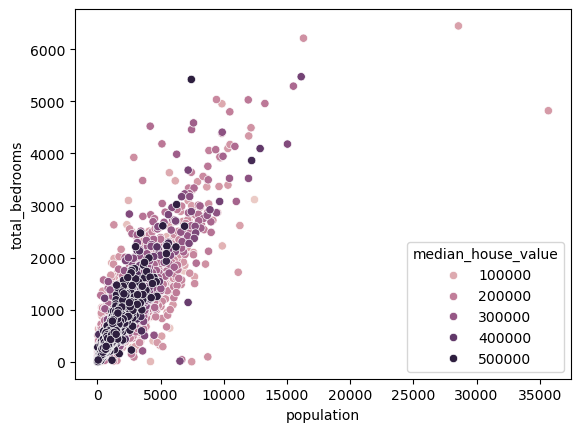

In [34]:
sns.scatterplot(data3.sort_values(by=target,ascending=True), x= 'population',y='total_bedrooms',hue=target)
plt.show()

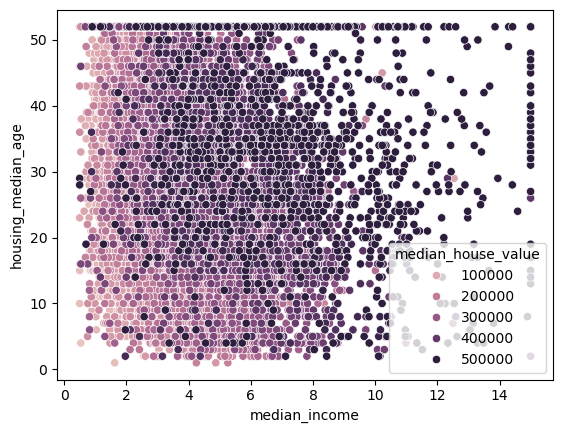

In [35]:
sns.scatterplot(data3.sort_values(by=target,ascending=True),
                x= 'median_income',y='housing_median_age',hue=target)
plt.show()